**Column Details:**
- **country**: Name of the country.
- **child_mort**: Number of child deaths per 1,000 live births (under 5 years).
- **exports**: Percentage of GDP that comes from exports.
- **health**: Percentage of GDP spent on healthcare.
- **imports**: Percentage of GDP spent on imports.
- **income**: Average income per person (per capita income in USD).
- **inflation**: Annual inflation rate (percentage change in prices).
- **life_expec**: Average life expectancy at birth (in years).
- **total_fer**: Average number of children born to a woman during her lifetime.
- **gdpp**: Gross Domestic Product per capita (in USD).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

import plotly.express as px
!pip install -U kaleido
import kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.9 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("/content/Country-data.csv")

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


In [4]:
df.shape

(167, 10)

In [5]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.00,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.00,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.00,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.00,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.00,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.00,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.00,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.00,2.95,1.51,1.15,1.79,2.41,3.88,7.49
gdpp,167.00,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


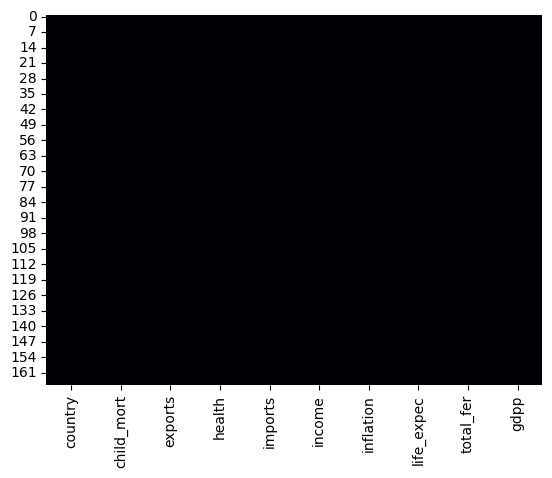

In [8]:
sns.heatmap(df.isnull(), cmap = 'magma', cbar=False);

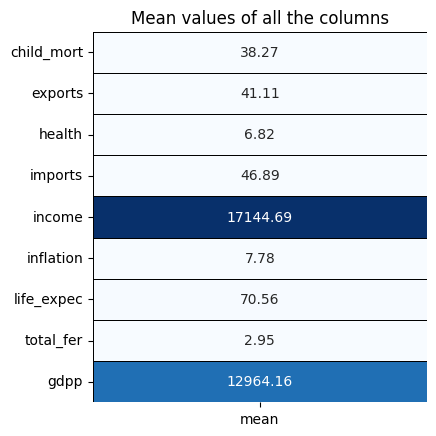

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
colors = ['#2bd0e4', '#1c6bdf']
plt.subplot(1, 1, 1)
sns.heatmap(df.describe().T[['mean']], cmap='Blues', annot=True, fmt='.2f',
            linecolor='black', linewidths=0.4, cbar=False);
plt.title("Mean values of all the columns");
fig.tight_layout(pad=3)

In [10]:
col = df.dtypes == 'object'
obj_cols = list(col[col].index)
col = df.dtypes != 'object'
num_cols = list(col[col].index)
print("Categorical Columns are: ", obj_cols)
print("Numerical Columns are: ", num_cols)

Categorical Columns are:  ['country']
Numerical Columns are:  ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


* We have only a few columns.
* Clearly 'country' is the only categorical column, rest are numerical columns.
* We separated categorical and numerical column.


#EDA

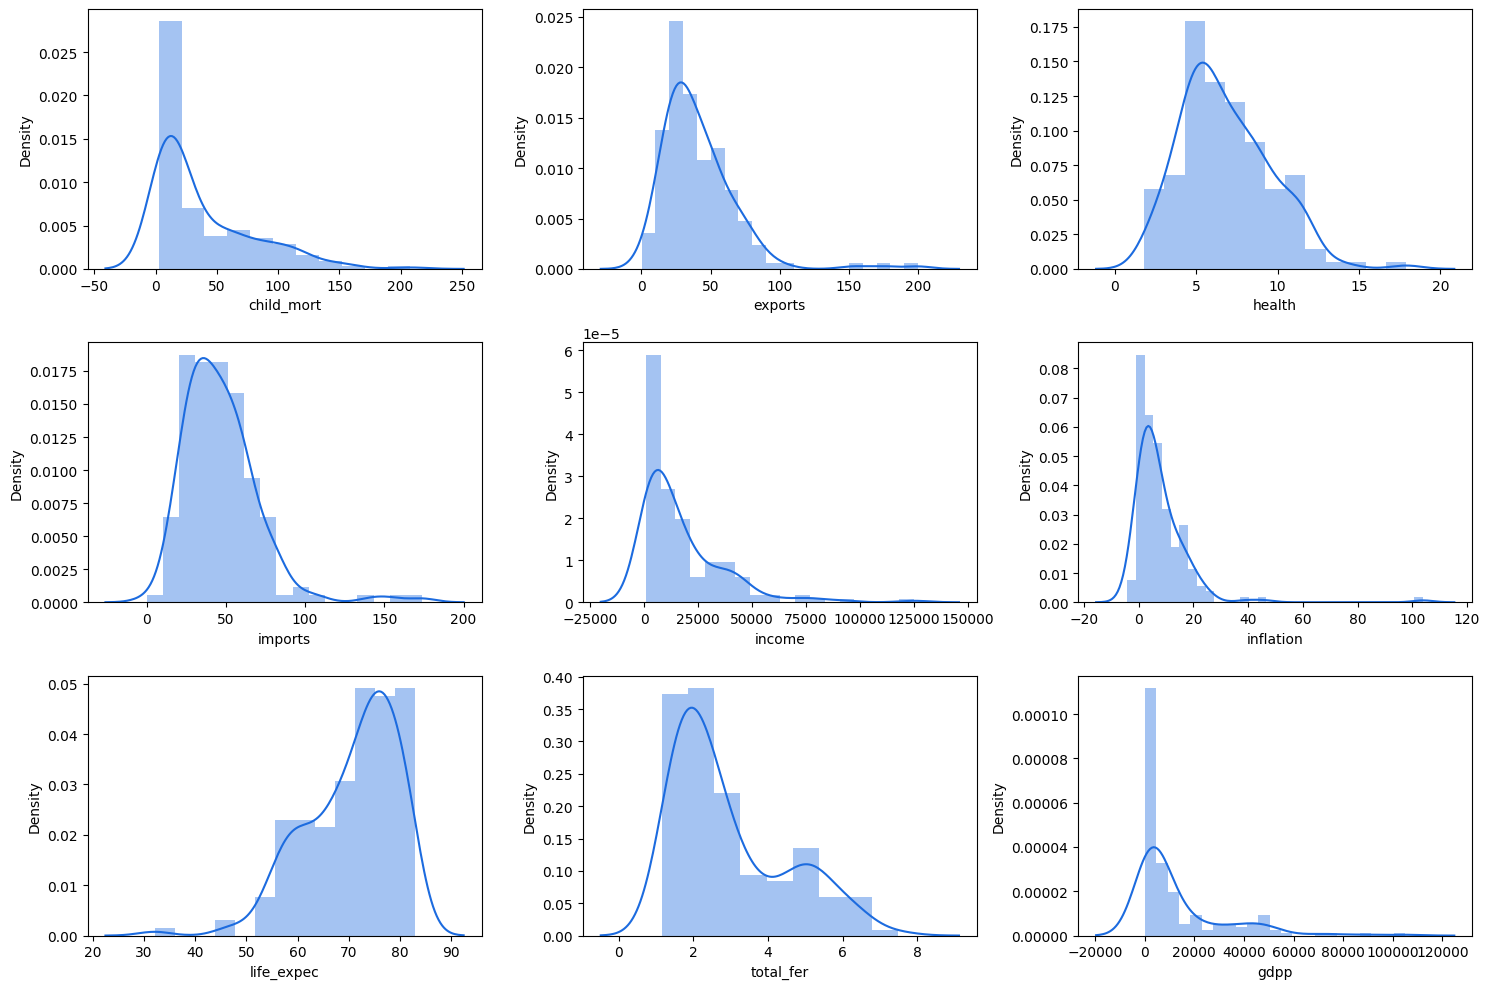

In [11]:
# let's observe the data distribution of all the numerical columns
plt.figure(figsize=(15, 10))
index=0
for col in num_cols:
    index += 1
    plt.subplot(3, 3, index)
    sns.distplot(df[col], color=colors[1])
    # plt.sup_title('Distribution of numerical features')
    plt.tight_layout()
plt.show()

In [12]:
len(df['country'].unique()) == len(df)

True

* Mostly all the columns appears to be right skewed or positively skewed distribution.
* Only column called ['life_expec'] appears left skewed or negatively skewed distribution.
* Only ['health'] column has normally distributed values.

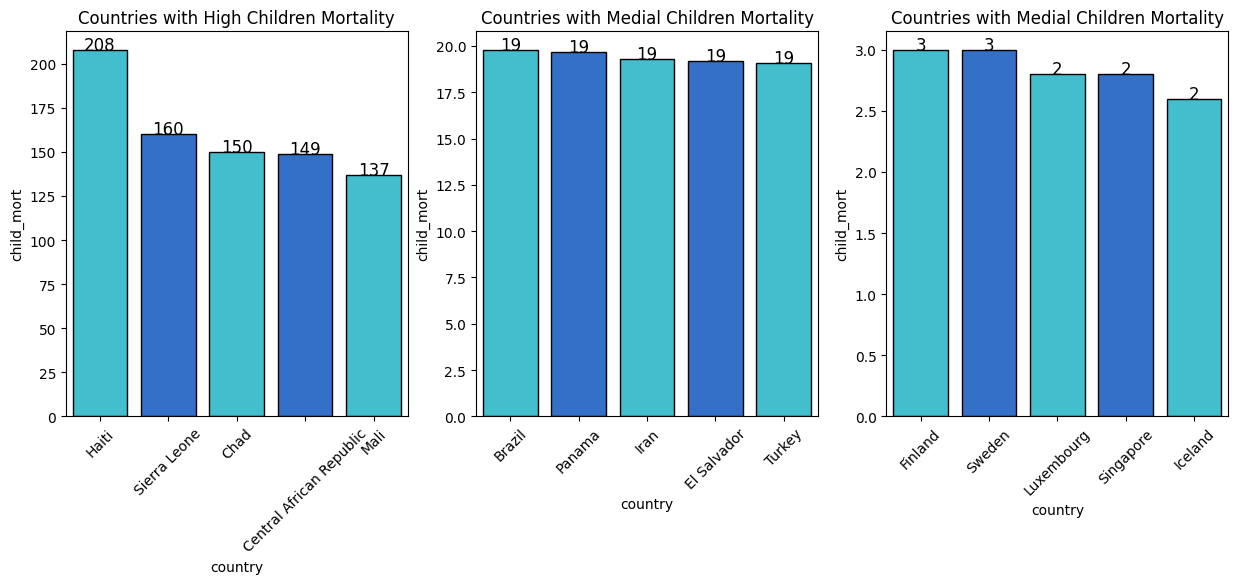

In [13]:
#Exploring child_mort column
fig = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x= 'country', y='child_mort',
                 data = df.sort_values(ascending=False, by='child_mort').iloc[:5],
                 palette = colors, edgecolor='black');
plt.title("Countries with High Children Mortality")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='child_mort',
                 data = df.sort_values(ascending=False, by='child_mort').iloc[81:86],
                 palette = colors, edgecolor='black');
plt.title("Countries with Medial Children Mortality")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='child_mort',
                 data = df.sort_values(ascending=False, by='child_mort').iloc[-5:],
                 palette = colors, edgecolor='black');
plt.title("Countries with Medial Children Mortality")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

* Haiti has the most death occuring to children, African countries has significant positions in the statistic.
* At the other extreme Asia and Europe countries has solid presence.

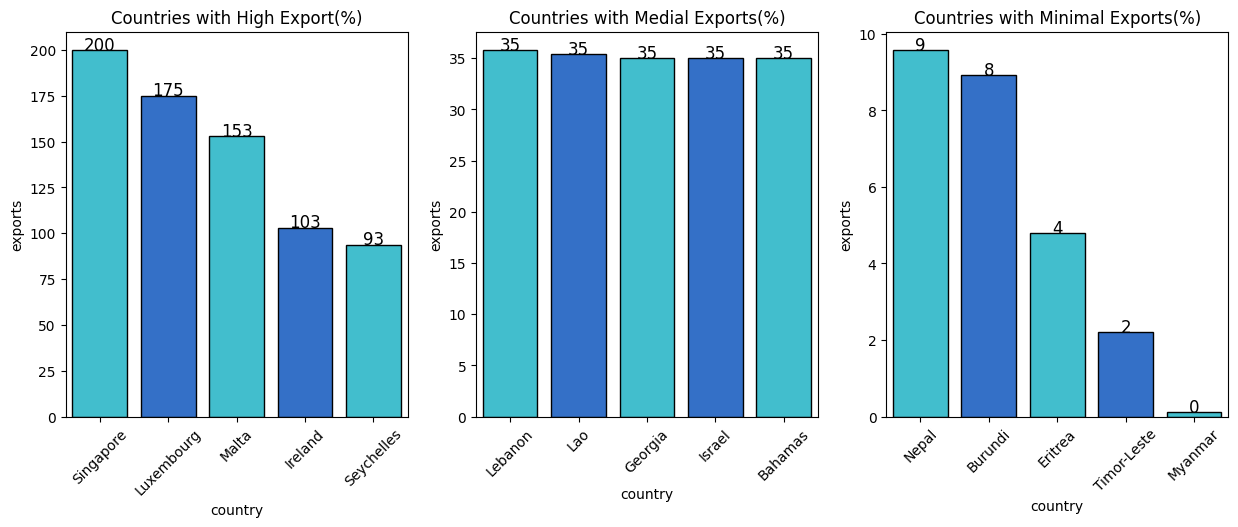

In [14]:
# Exploring Exorts column
fig = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x = 'country', y='exports',
                 data = df.sort_values(ascending=False, by='exports').iloc[:5],
                 palette = colors, edgecolor='black')
plt.title("Countries with High Export(%)")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='exports',
                 data=df.sort_values(ascending=False, by='exports').iloc[81:86],
                 palette=colors, edgecolor='black')
plt.title("Countries with Medial Exports(%)")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='exports',
                 data = df.sort_values(ascending=False, by='exports').iloc[-5:],
                 palette=colors, edgecolor='black')
plt.title("Countries with Minimal Exports(%)")
plt.xticks(rotation=(45))
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)


* Singapore has the highest export even if their population is not the largest.
* Afganistan and Nepal are present at the lower end of export rankings and apparently Myanmar has no export at all.

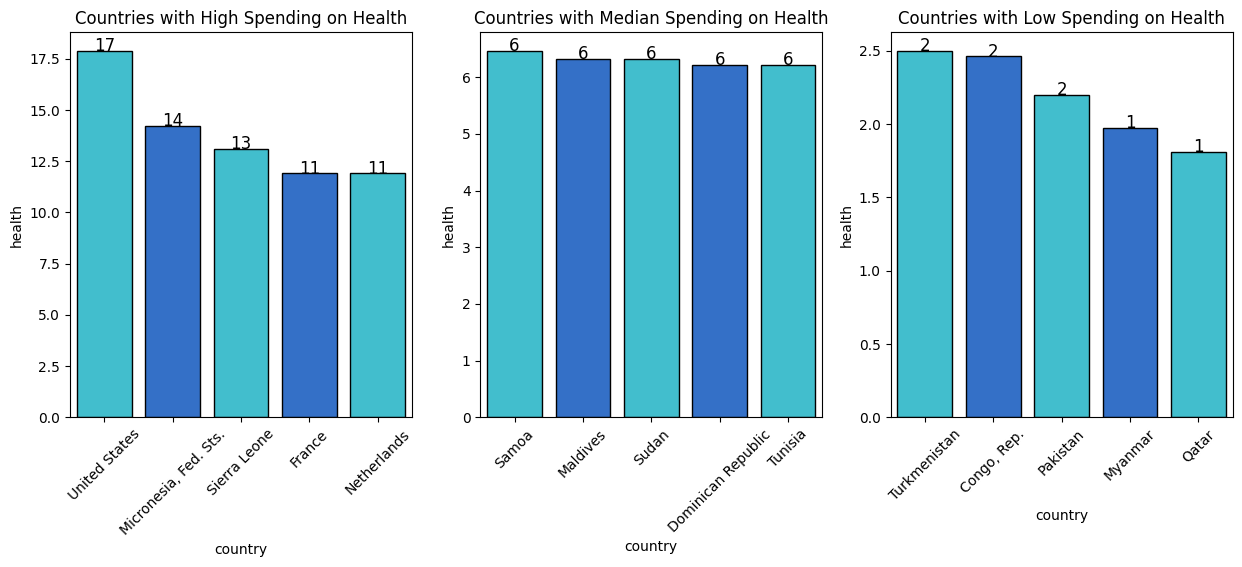

In [15]:
#  Exploring Health column
plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x = 'country', y='health',
                 data = df.sort_values(ascending=False, by='health').iloc[:5],
                 palette=colors, edgecolor='black')
plt.title("Countries with High Spending on Health")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='health',
                 data=df.sort_values(ascending=False, by='health').iloc[81:86],
                 palette=colors, edgecolor='black')
plt.title("Countries with Median Spending on Health")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='health',
                 data=df.sort_values(ascending=False, by='health').iloc[-5:],
                 palette=colors, edgecolor='black')
plt.title('Countries with Low Spending on Health')
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)


* US spends the most for health overall by quite a margin.
* Samoa, Maldieves and similar contries comes in the median of the spectrum.
* Asian country hardly spend for health.

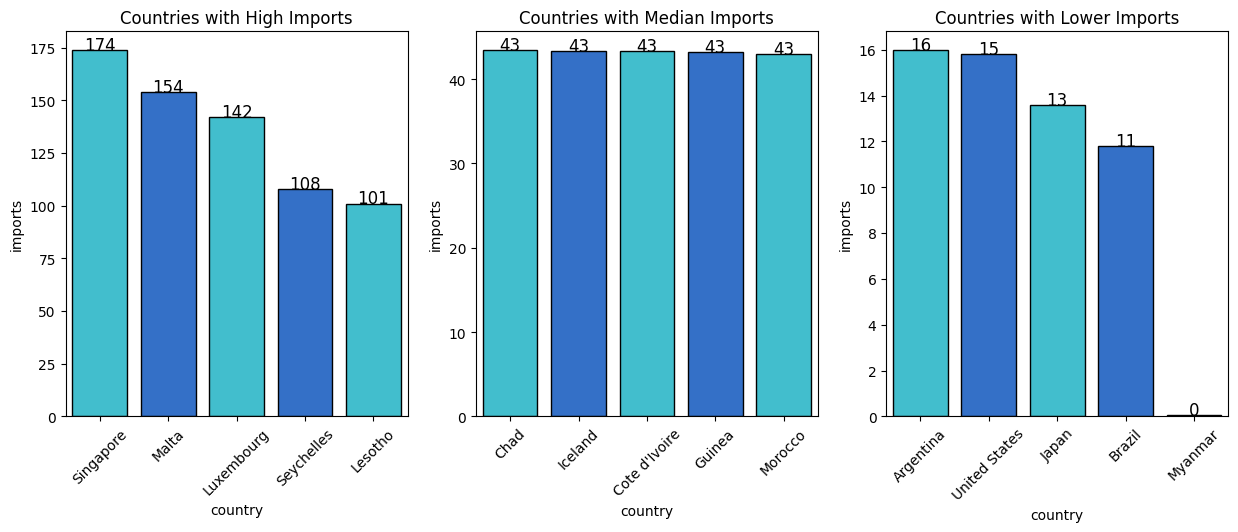

In [16]:
# Exploring imports column
plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x='country', y='imports',
                 data=df.sort_values(ascending=False, by='imports').iloc[:5],
                 palette=colors, edgecolor='black')
plt.title("Countries with High Imports")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='imports',
                 data=df.sort_values(ascending=False, by='imports').iloc[81:86],
                 palette=colors, edgecolor='black')
plt.title("Countries with Median Imports")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='imports',
                 data=df.sort_values(ascending=False, by='imports').iloc[-5:],
                 palette=colors, edgecolor='black')
plt.title("Countries with Lower Imports")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

* We can observe that Singapore is first in imports as well as exports.
* Contries like Chad, Iceland comes at the median level of imports.
* Myanmar has no imports at all, brazil, japan and US comes under the least import rates.

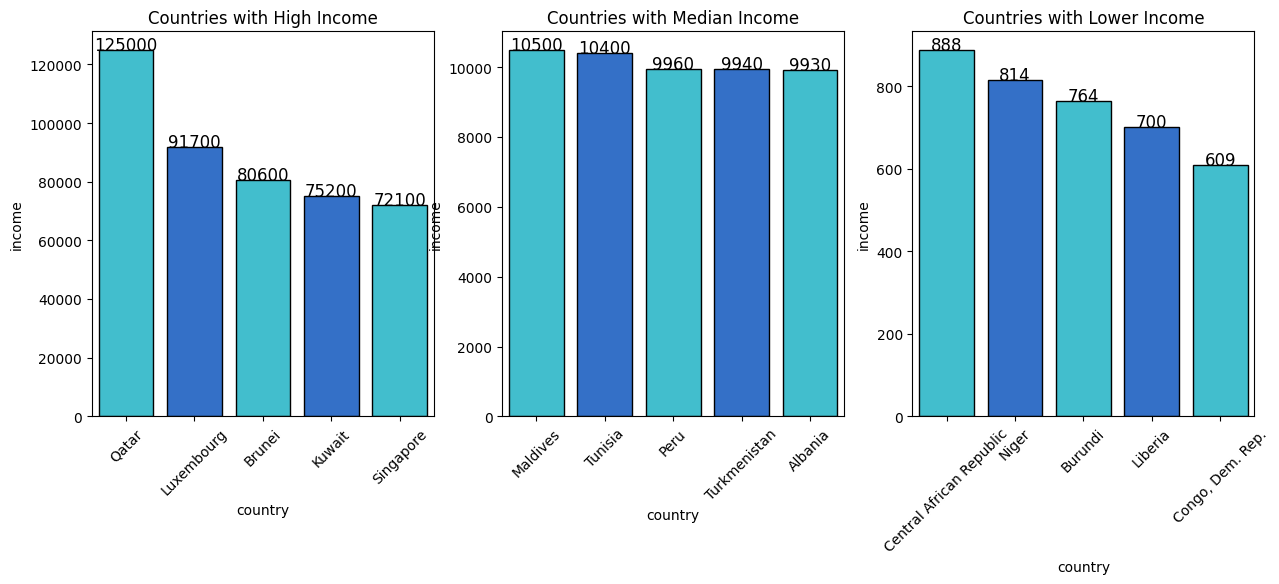

In [17]:
# Exploring income column

plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x='country', y='income',
                 data=df.sort_values(ascending=False, by='income').iloc[:5],
                 palette=colors, edgecolor='black')
plt.title("Countries with High Income")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='income',
                 data=df.sort_values(ascending=False, by='income').iloc[81:86],
                 palette=colors, edgecolor='black')
plt.title("Countries with Median Income")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='income',
                 data=df.sort_values(ascending=False, by='income').iloc[-5:],
                 palette=colors, edgecolor='black')
plt.title("Countries with Lower Income")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

* We can observe Qatar has the most Income, followed by Luxembourg, Brunei and so on.
* Countries like Maldivies, Tunisia and so on follows median range of Income.
* Lastly countries like Africa, Niger has least amount of Income.

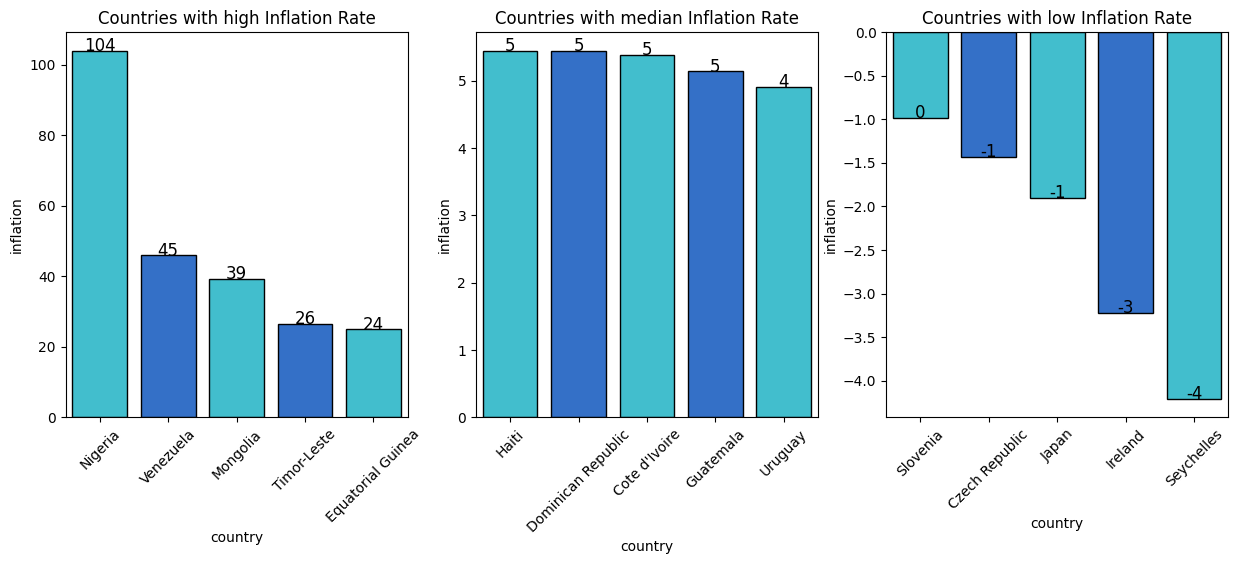

In [18]:
# Let's explore the inflation column
plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x='country', y='inflation',
                 data = df.sort_values(ascending=False, by='inflation').iloc[:5],
                 palette=colors, edgecolor='black')
plt.title("Countries with high Inflation Rate")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='inflation',
                 data = df.sort_values(ascending=False, by='inflation').iloc[81:86],
                 palette=colors, edgecolor='black')
plt.title("Countries with median Inflation Rate")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='inflation',
                 data = df.sort_values(ascending=False, by='inflation').iloc[-5:],
                 palette=colors, edgecolor='black')
plt.title("Countries with low Inflation Rate")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

* We can see Nigeria has the highest inflation rate by a very large margine.
* Countries like Haiti and so on observed in the second subplot has median inflation rate.
Few Countries has negative inflation rate as well.
* Countries like Slovenia are with 0 inflation rate.

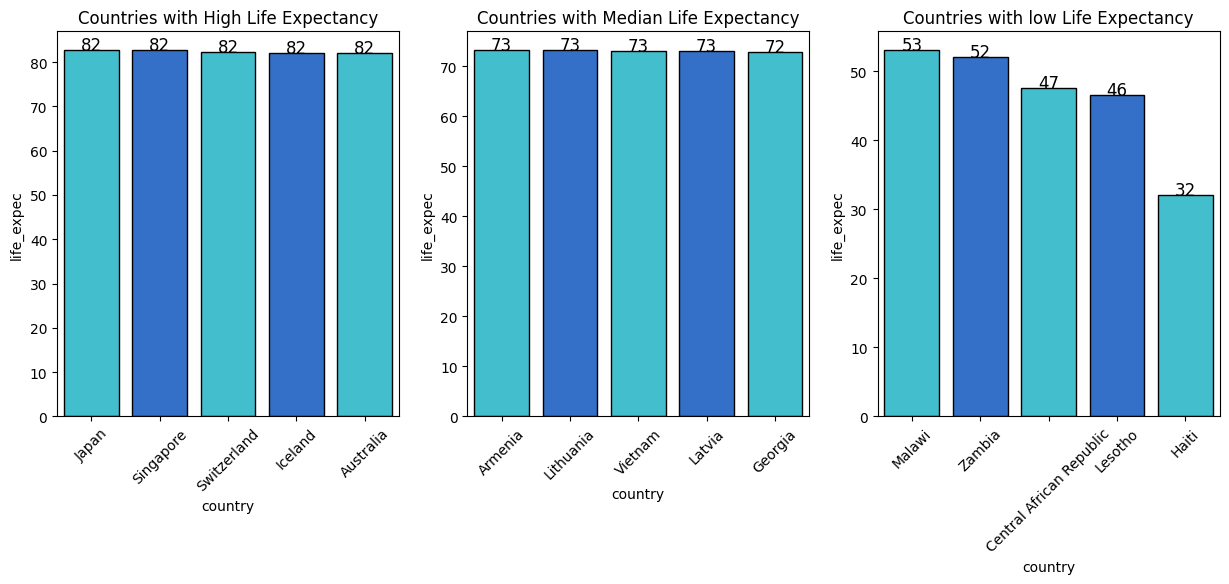

In [19]:
# Exploring life_expec colun
plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x='country', y='life_expec',
                 data = df.sort_values(ascending=False, by='life_expec').iloc[:5],
                 palette=colors, edgecolor='black')
plt.title("Countries with High Life Expectancy")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='life_expec',
                 data = df.sort_values(ascending=False, by='life_expec').iloc[81:86],
                 palette=colors, edgecolor='black')
plt.title("Countries with Median Life Expectancy")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='life_expec',
                 data = df.sort_values(ascending=False, by='life_expec').iloc[-5:],
                 palette=colors, edgecolor='black')
plt.title("Countries with low Life Expectancy")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

* Top developed countries are expected to have high life expectancy.
* Countries like Armenia, Latvia covers the median half of the life expectancy.
* Haiti is the country expected to have the least life expectancy.

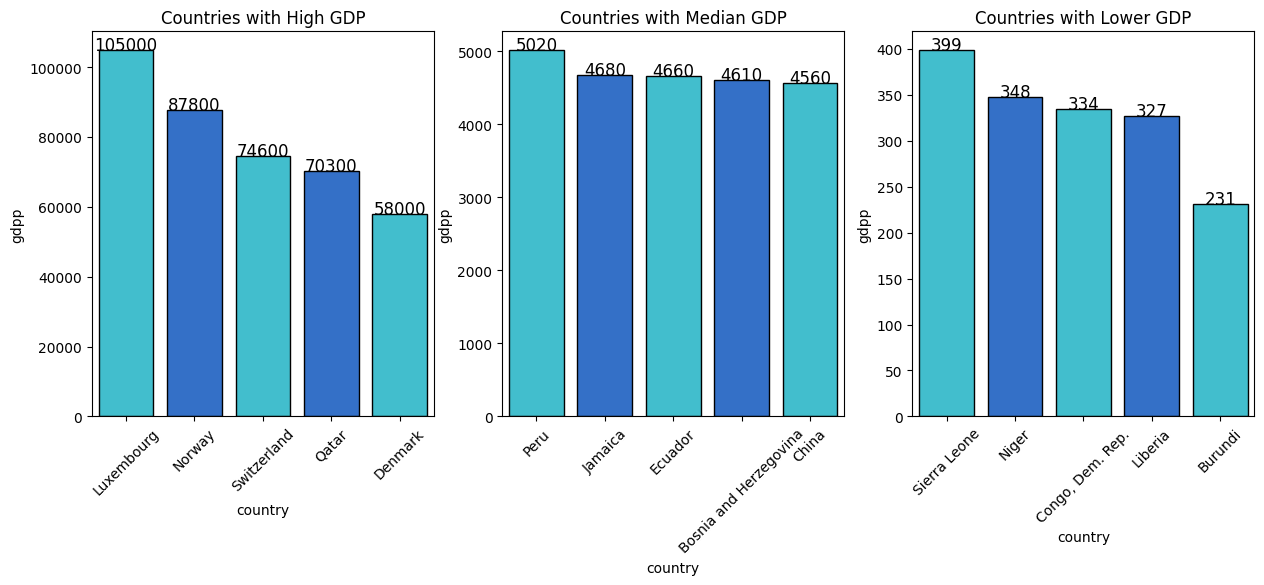

In [20]:
plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x='country', y='gdpp',
                 data = df.sort_values(ascending=False, by='gdpp').iloc[:5],
                 palette=colors, edgecolor='black')
plt.title("Countries with High GDP")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='gdpp',
                 data = df.sort_values(ascending=False, by='gdpp').iloc[81:86],
                 palette=colors, edgecolor='black')
plt.title("Countries with Median GDP")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='gdpp',
                 data = df.sort_values(ascending=False, by='gdpp').iloc[-5:],
                 palette=colors, edgecolor='black')
plt.title("Countries with Lower GDP")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

* Luxembourg has the most GDP and has a wide gap to the next country Norway.
* Countries like Peru, Jamaica covers the median half of the chart.
* Burundi has the least amount of GDP in their country.

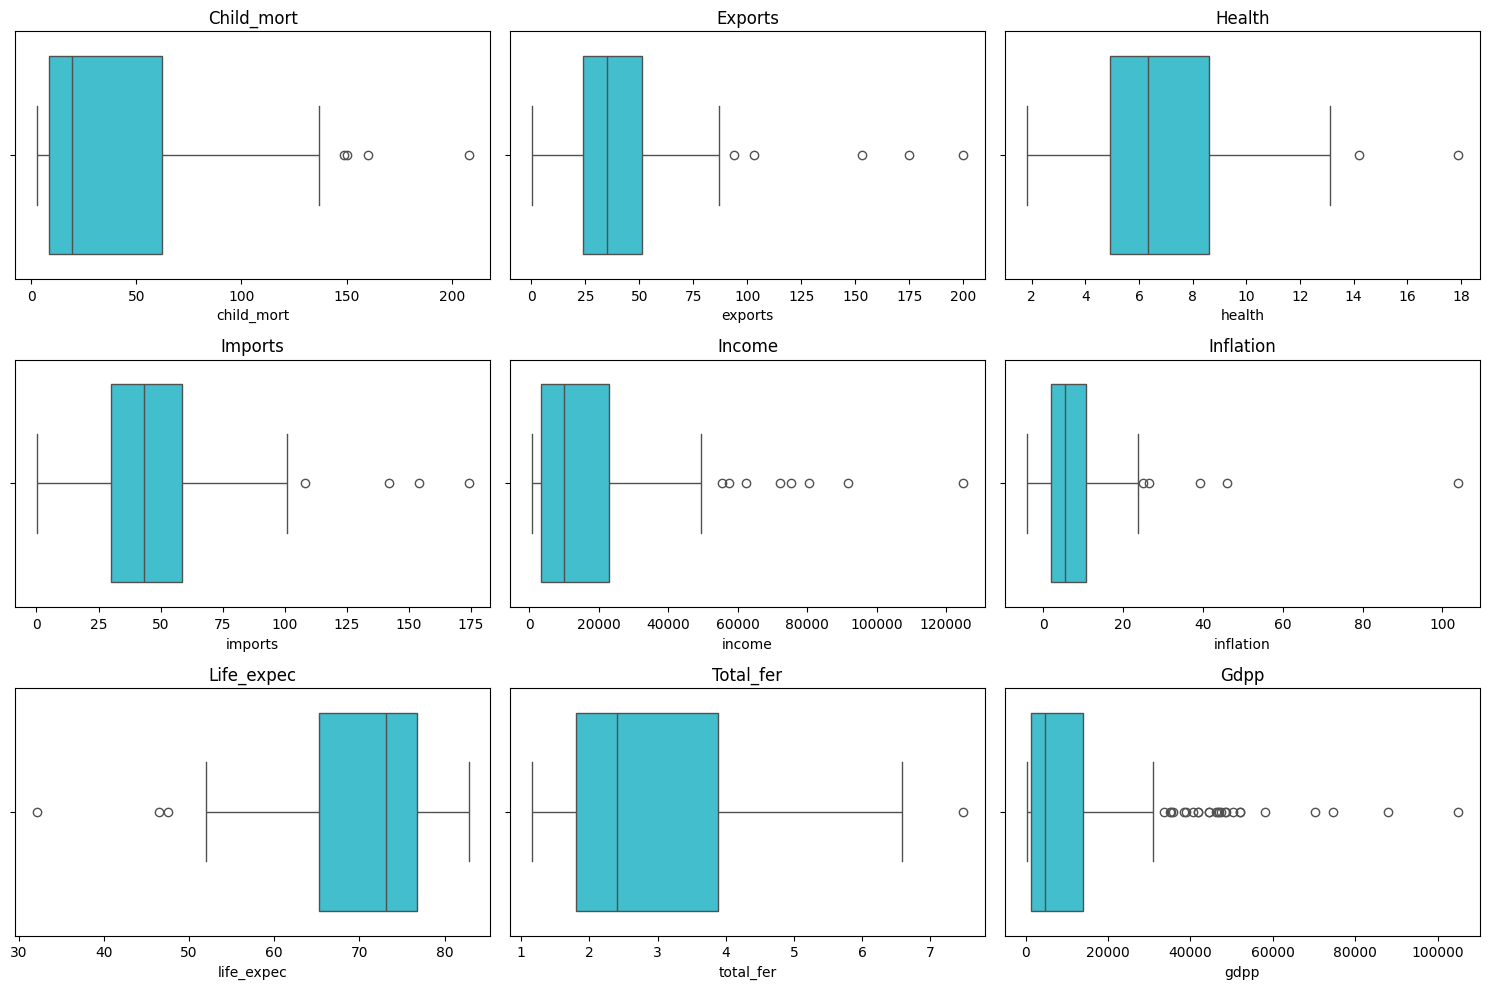

In [21]:
plt.figure(figsize=(15, 10))
index = 0
for col in df.columns[1:]:
    index += 1
    plt.subplot(3, 3, index)
    sns.boxplot(x=df[col], color=colors[0])
    plt.title(col.capitalize())
    plt.tight_layout()
plt.show()

EDA SUMMARY:


*   From all the visualizations we can observe the following details.
*   African countries have very poor health conditions like child_mort, low_expec and total_fer.
*    These are pretty serious issues and every countries should try and help the similar countries, Haiti has the top spot for child_mort also Asian anf European countries are present at the other end of it.
*   US are the spenders on their Health although they are not present at the top of the life_expc chartand total_fer, Asian countries crowd the lower life_expec are present in the lower 5 of health.
*   Singapore, Malta and similar countries are present in top for imports and exports.



#Feature Engineering

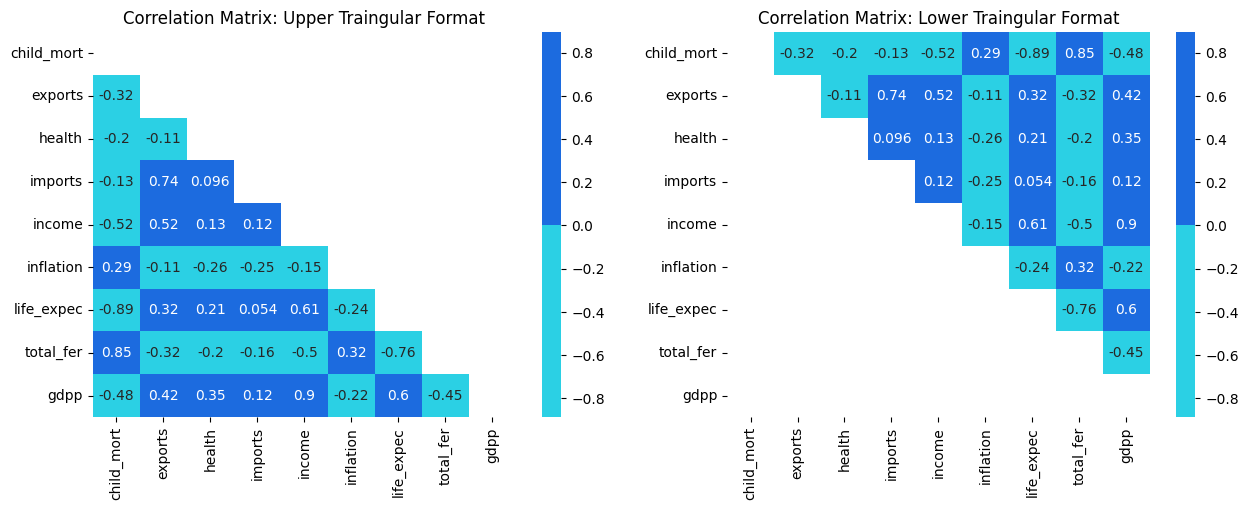

In [22]:
ut = np.triu(df.corr(numeric_only=True))
lt = np.tril(df.corr(numeric_only=True))

fig, ax = plt.subplots(nrows=1, ncols = 2, figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.heatmap(df.corr(numeric_only=True), cmap=colors, annot=True, cbar=True, mask=ut)
plt.title('Correlation Matrix: Upper Traingular Format')

plt.subplot(1, 2, 2)
sns.heatmap(df.corr(numeric_only=True), cmap=colors, annot=True, cbar=True, mask =lt)
plt.title("Correlation Matrix: Lower Traingular Format")
plt.show()

* We can see many features are correlated to each other.
* When income, gdpp and exports decreases, child_mort increases. We can see Economy has major impact on child_mort rate.
* Increase in gdpp, income and imports are directly proportional to exports.
* Spending on health has a small rise in life_expec and also decrease in child_mort.
* income and gdpp has ery high correlation which is to be expected.
* High inflation has negative effect on the finance features.

* The 3 categoris of the features are:
  * health: child_mort, life_expec, total_fer.
  * trade: imports, exports
  * finance: income, inflation, gdpp
* Hence we can engineer these features into these catefories and normalize them.

In [23]:
df1 = pd.DataFrame()

df1['Health'] = (df['child_mort']/df['child_mort'].mean()) + (df['health']/df['health'].mean()) + (df['life_expec']/df['life_expec'].mean()) + (df['total_fer']/df['total_fer'].mean())
df1['Trade'] = (df['imports']/df['imports'].mean()) + (df['exports']/df['exports'].mean())
df1['Finance'] = (df['income']/df['income'].mean()) + (df['inflation']/df['inflation'].mean()) + (df['gdpp']/df['gdpp'].mean())
df1.head()

,Health,Trade,Finance
0,6.24,1.20,1.35
1,3.04,1.72,1.47
2,3.39,1.60,3.17
3,6.47,2.43,3.49
4,2.96,2.36,2.24


In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

mms = MinMaxScaler()
ss = StandardScaler()

df1[['Health','Trade','Finance']] = mms.fit_transform(df1)
df1.insert(loc=0, value=list(df['country']), column='Country')
df1.head()

,Country,Health,Trade,Finance
0,Afghanistan,0.63,0.14,0.08
1,Albania,0.13,0.20,0.09
2,Algeria,0.18,0.19,0.21
3,Angola,0.66,0.28,0.24
4,Antigua and Barbuda,0.12,0.28,0.15


In [25]:
df2 = df.copy(deep=True)

col = list(df.columns)
col.remove('health'); col.remove('country')

df2['health'] = ss.fit_transform(df2[['health']])      #standardizarion

for i in col:
    df2[i] = mms.fit_transform(df2[[i]])
df2.drop(columns='country', inplace=True)
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.43,0.05,0.28,0.26,0.01,0.13,0.48,0.74,0.00
1,0.07,0.14,-0.10,0.28,0.07,0.08,0.87,0.08,0.04
2,0.12,0.19,-0.97,0.18,0.10,0.19,0.88,0.27,0.04
3,0.57,0.31,-1.45,0.25,0.04,0.25,0.55,0.79,0.03
4,0.04,0.23,-0.29,0.34,0.15,0.05,0.88,0.15,0.11


* Normalizing and Standardizing the data is expremely important before passing the data for PCA Transoformation.

In [26]:
from sklearn.decomposition import PCA

pca = PCA()
pca_df2 = pd.DataFrame(pca.fit_transform(df2))
pca.explained_variance_

array([1.01740511, 0.13090418, 0.03450018, 0.02679822, 0.00979752,
       0.00803398, 0.00307055, 0.00239976, 0.00179388])

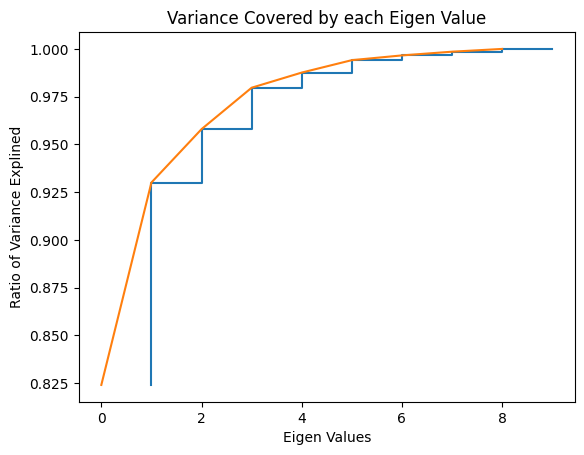

In [27]:
plt.step(list(range(1, 10)), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Eigen Values')
plt.ylabel('Ratio of Variance Explined')
plt.title("Variance Covered by each Eigen Value")
plt.show()

* From the graph it is clear how the data is being varied over cummulative summation values, typically we consider uptop 95% of ratio of variance.
* Here we are choosing only 2 features meaning only 2 features are dominating rest of the other features.

In [28]:
pca_df2 = pca_df2.drop(columns = [3,4,5,6,7,8])
pca_df2.head()

,0,1,2
0,0.22,0.64,0.09
1,-0.08,-0.17,-0.21
2,-0.96,-0.13,-0.13
3,-1.51,0.47,0.28
4,-0.26,-0.24,-0.06


* Now we have finally reduced the dimensions! Now we will move to modelling part.

#Modeling

In [29]:
m1 = df1.drop(columns = ['Country']).values
m2 = pca_df2.values

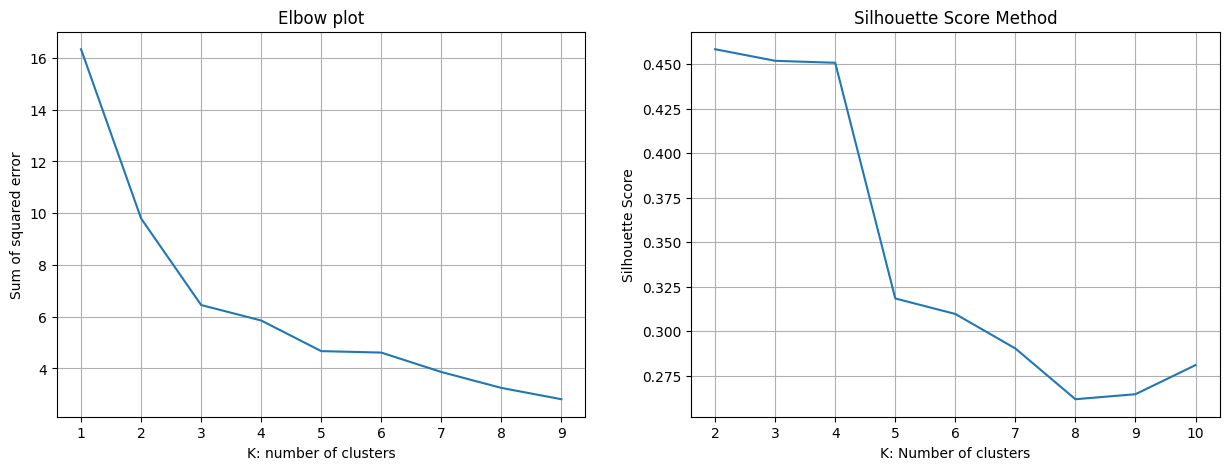

In [30]:
sse = {}
sil = []
kmax = 10
fig = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Elbow method
plt.subplot(1, 2, 1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000)
    kmeans.fit(m1)
    sse[k] = kmeans.inertia_

sns.lineplot(x=list(sse.keys()), y = list(sse.values()))
plt.title("Elbow plot")
plt.xlabel("K: number of clusters")
plt.ylabel('Sum of squared error')
plt.grid()

# Silhouette Score Method
plt.subplot(1, 2, 2)
for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x=range(2, kmax+1), y=sil)
plt.title("Silhouette Score Method")
plt.xlabel("K: Number of clusters")
plt.ylabel('Silhouette Score')
plt.grid()

plt.show()

From both the method we can pick k=3.

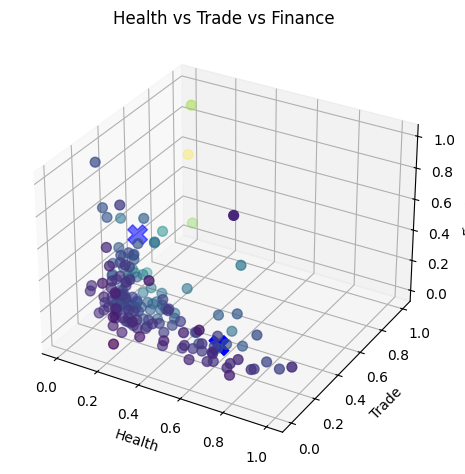

In [31]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

model = KMeans(n_clusters=3, max_iter=1000)
model.fit(m1)

cluster = model.cluster_centers_
centroids = cluster
labels = model.labels_
df['Class'] = labels
df1['Class'] = labels

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df1['Health']
y = df1['Trade']
z = df1['Finance']

ax.scatter(x, y, z, c=y, s=50)
ax.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker="X", s=200, color='b', label='centroid')

plt.title("Health vs Trade vs Finance")
ax.set_xlabel("Health")
ax.set_ylabel("Trade")
ax.set_zlabel("Finance")

plt.tight_layout()
plt.show()

* We can observe the 3 cluster centers to be varying quite a bit which is to be expected.
* However we can clearly see the classes are defined in these

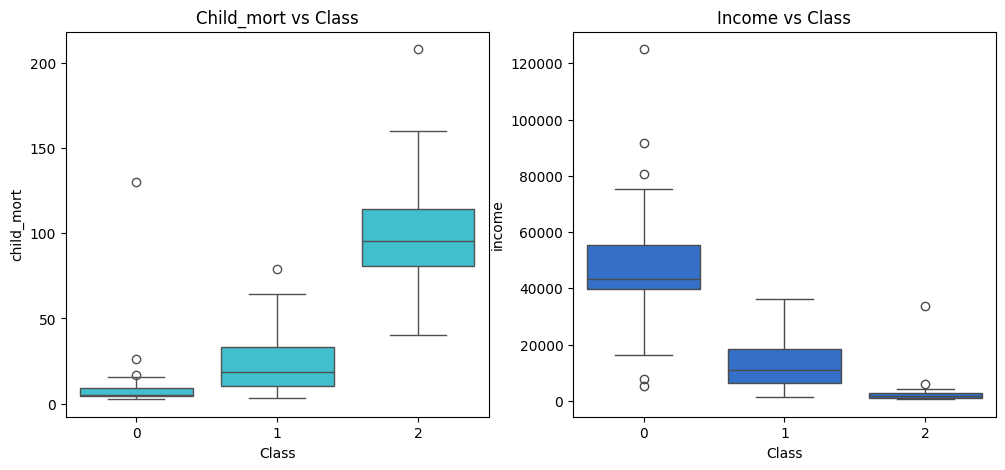

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Class', y='child_mort', data=df, color=colors[0])
plt.title("Child_mort vs Class")

plt.subplot(1, 2, 2)
sns.boxplot(x='Class', y='income', data=df, color=colors[1])
plt.title("Income vs Class")
plt.show()

From above we can conclude:
* 0: Might Need Help
* 1: Help Needed
* 2: No Help Needed

In [33]:
df1['Class'].loc[df1['Class'] == 0] = "Might Need Help"
df1['Class'].loc[df1['Class'] == 1] = "Help Needed"
df1['Class'].loc[df1['Class'] == 2] = "No Help Needed"

fig = px.choropleth(df1[['Country','Class']],
                    locationmode='country names',
                    locations = 'Country',
                    title = "Needed Help Per Country (World)",
                    color=df1['Class'],
                    color_discrete_map={'Might Need Help':'Red',
                                        'Help Needed': 'Green',
                                        'No Help Needed':'Yellow'})

fig.update_geos(fitbounds = 'locations', visible=True)
fig.update_layout(legend_title_text = 'Labels', legend_title_side='top', title_pad_l=260,title_y=0.86)
fig.show(engine='kaleido')

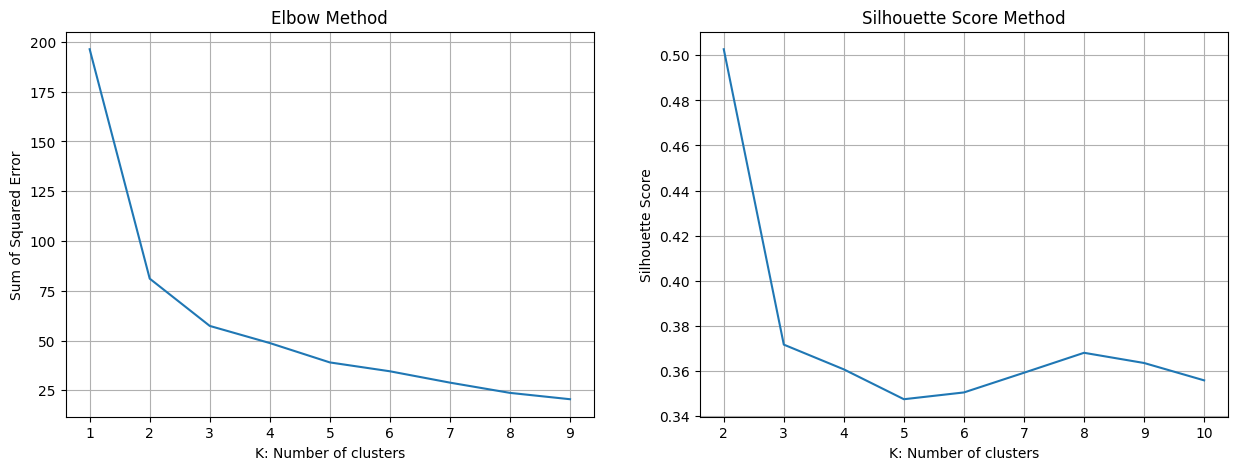

In [34]:
sse = {}; sil = []; kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plotting elbow method
plt.subplot(1, 2, 1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000)
    kmeans.fit(m2)
    sse[k] = kmeans.inertia_

sns.lineplot(x = list(sse.keys()), y=list(sse.values()))
plt.title('Elbow Method')
plt.xlabel("K: Number of clusters")
plt.ylabel("Sum of Squared Error")
plt.grid()

#Plotting silhouette score method
plt.subplot(1, 2, 2)
for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))

sns.lineplot(x=range(2, kmax+1), y=sil);
plt.title("Silhouette Score Method")
plt.xlabel("K: Number of clusters")
plt.ylabel("Silhouette Score")
plt.grid()

plt.show()

From the above 2 methods we can select k=3

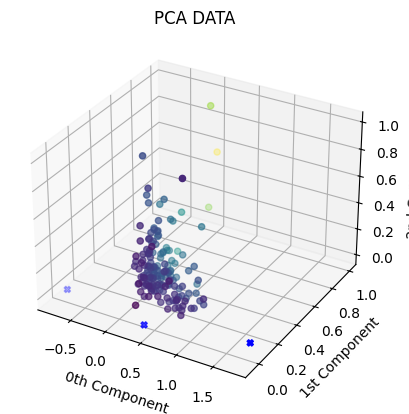

In [35]:
model = KMeans(n_clusters = 3, max_iter=1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids=np.array(cluster)
labels = model.labels_
df['Class'] = labels
pca_df2['Class'] = labels

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker='X', color='b')
plt.title("PCA DATA")
ax.set_xlabel('0th Component')
ax.set_ylabel('1st Component')
ax.set_zlabel('2nd Component')
ax.scatter(x, y, z, c=y)
plt.show()

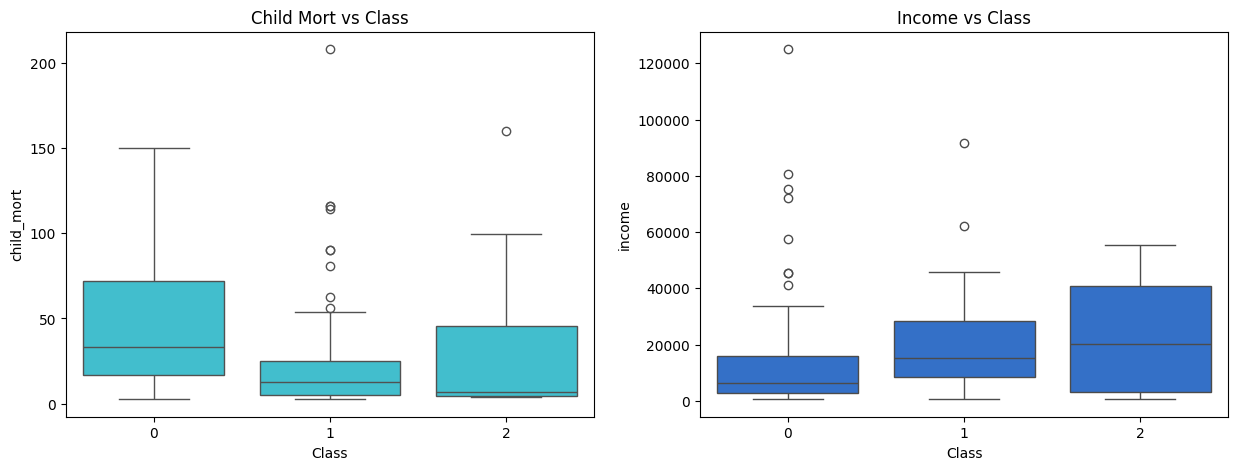

In [36]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x = 'Class', y = 'child_mort', data = df, color = colors[0])
plt.title('Child Mort vs Class')
plt.subplot(1, 2, 2)
sns.boxplot(x = 'Class', y = 'income', data = df, color=colors[1])
plt.title("Income vs Class")
plt.show()

* From the above plot we can conclude:
  * 0: No Help Needed
  * 1: Help Needed
  * 2: Might Need Help

In [38]:
pca_df2.insert(0, column = 'Country', value = df['country'])

pca_df2['Class'].iloc[pca_df2['Class'] == 0] = "No Help Needed"
pca_df2['Class'].iloc[pca_df2['Class'] == 1] = "Help Needed"
pca_df2['Class'].iloc[pca_df2['Class'] == 2] = "Might Need Help"

fig = px.choropleth(pca_df2[['Country','Class']],
                    locationmode = 'country names',
                    locations = 'Country',
                    title = "Needed Help per country(World)",
                    color = pca_df2['Class'],
                    color_discrete_map={'Help Needed':'Red',
                                        'Might Need Help':'Yellow',
                                        'No Help Needed':'Green'})

fig.update_geos(fitbounds = "locations", visible = True)
fig.update_layout(legend_title_text = 'Labels',legend_title_side = 'top',title_pad_l = 260,title_y = 0.86)
fig.show(engine = 'kaleido')

# DBSCAN Algorithm
* DBSCAN Clustering is a density based clustering algorithm that is used for unsupervised learning problems.

In [39]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

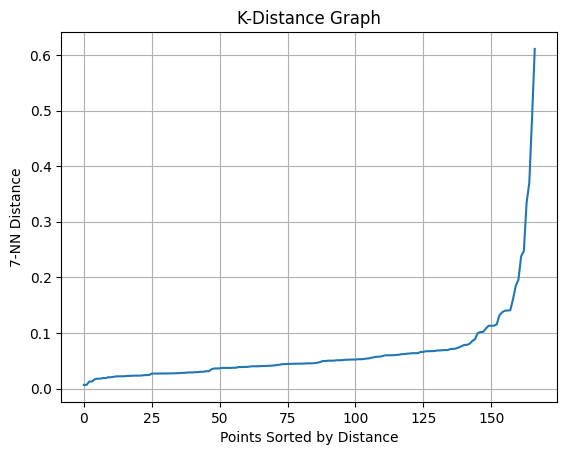

In [42]:
knn = NearestNeighbors(n_neighbors = 7)
model = knn.fit(m1)
distances, indices = knn.kneighbors(m1)

distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.grid()
plt.plot(distances);
plt.xlabel('Points Sorted by Distance')
plt.ylabel('7-NN Distance')
plt.title('K-Distance Graph')
plt.show()

* We select minPts = 8 i.r >= 2*3 features
* The value assigned to the n_neighbors minPts - 1
* From the graph above, we select:
  * eps = 0.08

In [45]:
db = DBSCAN(eps = 0.08, min_samples = 8).fit(m1)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Number of CLusters: ", n_clusters_)
print('Number of Outliers: ', n_noise_)
df['Class'] = labels; df1['Class'] = labels

Number of CLusters:  3
Number of Outliers:  67


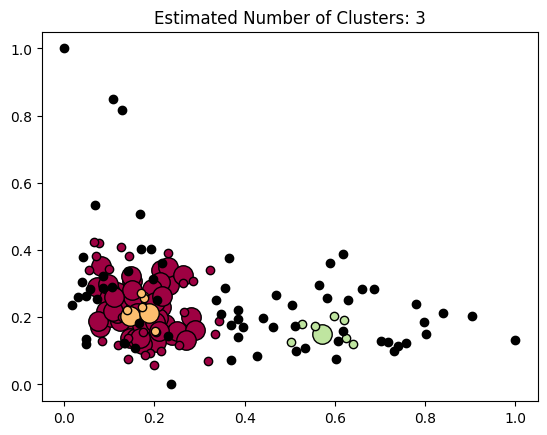

In [48]:
unique_labels = set(labels)
colors =[plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
       col = [0, 0, 0, 1]
    class_member_mask = labels == k

    xy = m1[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor = tuple(col), markeredgecolor = 'k', markersize=14)

    xy = m1[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor = tuple(col), markeredgecolor = 'k', markersize=6)

plt.title("Estimated Number of Clusters: %d"%n_clusters_)
plt.show()